# Practica Nro 2 INF672 - MACHINE LEARNING 
## Predicción del costo anual de un seguro médico

**Nombre:** Eddy Edson Quispe Condori   
**RU:** 120777



In [1]:
#Importamos las librerias 

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
#Cargar y conocer los datos 

df = pd.read_csv("insurance.csv")

print(df.shape)

print(df.head())

df.info()

(1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


**1. ¿Cuántos asegurados y cuántas columnas tiene el dataset?**

El dataset contiene 1338 asegurados y 7 columnas. Cada registro corresponde a una persona asegurada.

**2. ¿Qué representa una fila?**

Cada fila representa a un asegurado, con información sobre su edad, sexo, índice de masa corporal, número de hijos o dependientes, si fuma, su región de residencia y el costo médico anual.

**3. ¿Qué columnas contienen texto y cuáles contienen números?**

Las columnas que contienen texto son sex, smoker y region.

Las columnas numéricas son age, bmi, children y charges.

**4. ¿Cuál es la variable que queremos predecir?**

La variable que queremos predecir es charges, que representa el costo médico anual facturado por el seguro en dólares.

In [3]:
# Separar los datos

y = df["charges"]
X = df.drop("charges", axis=1)

# Comprobamos
print("X:")
print(X.head())

print("\ny:")
print(y.head())

X:
   age     sex     bmi  children smoker     region
0   19  female  27.900         0    yes  southwest
1   18    male  33.770         1     no  southeast
2   28    male  33.000         3     no  southeast
3   33    male  22.705         0     no  northwest
4   32    male  28.880         0     no  northwest

y:
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


In [4]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [5]:
#Comvertir las varibles en categorias
X = pd.get_dummies(X, drop_first=True)
print(X.head())

   age     bmi  children  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0     False        True             False   
1   18  33.770         1      True       False             False   
2   28  33.000         3      True       False             False   
3   33  22.705         0      True       False              True   
4   32  28.880         0      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [6]:
#Comprobamos las columnas 
print(X.columns)
print(X.shape)
print(y.shape)

Index(['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='str')
(1338, 8)
(1338,)



**1. ¿En cuántas columnas se convirtieron las 6 variables originales?**

Las 6 variables originales se convirtieron en **8 columnas** después de aplicar la codificación con `pd.get_dummies()`.

Las columnas resultantes fueron:

* `age`
* `bmi`
* `children`
* `sex_male`
* `smoker_yes`
* `region_northwest`
* `region_southeast`
* `region_southwest`

**2. ¿Qué categoría de cada variable quedó como referencia?**

* `sex`: **female** quedó como referencia.
* `smoker`: **no** quedó como referencia.
* `region`: **northeast** quedó como referencia.

Las variables numéricas (`age`, `bmi` y `children`) no tienen categorías de referencia porque ya eran numéricas.

**3. ¿Qué hace `drop_first=True` y por qué no se pierde información?**

`drop_first=True` elimina la primera categoría de cada variable categórica y la utiliza como **categoría de referencia**.

No se pierde información porque cuando una observación tiene **0 en todas las columnas creadas para una variable**, significa que pertenece a la categoría que fue eliminada y quedó como referencia.

Por ejemplo, para `sex` solo tenemos la columna `sex_male`:

* `sex_male = 1` → male
* `sex_male = 0` → female

Por lo tanto, no es necesario crear otra columna para `female`.


## Dividimos los datos en entranamiento y prueba 

**80%** -> entrenamiento  
**20%** -> prueba 

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
#Comprobacion de los tamaños
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1070, 8)
X_test: (268, 8)
y_train: (1070,)
y_test: (268,)



**1. ¿Por qué no se debe evaluar el modelo con los mismos datos con los que se entrenó?**

Porque el modelo podría aprender demasiado bien los datos de entrenamiento y obtener resultados aparentemente buenos. Para saber si realmente puede **predecir nuevos casos**, se deben utilizar datos que el modelo no haya visto durante el entrenamiento. Por eso se separan los datos en un conjunto de **entrenamiento** y otro de **prueba**.

**2. ¿Qué función cumple `random_state` y qué pasaría con tus resultados si no lo fijaras?**

`random_state` permite establecer una **semilla para que la división de los datos sea reproducible**. En nuestro caso usamos `random_state=42`, por lo que cada vez que ejecutemos el código obtendremos la misma división entre datos de entrenamiento y prueba.

Si no fijáramos `random_state`, los datos podrían dividirse de manera diferente cada vez que ejecutemos el código, por lo que también podrían cambiar los resultados de las métricas del modelo, como **MAE, RMSE y R^2**.


In [9]:
#Importar el modelo 
from sklearn.linear_model import LinearRegression
#Crear el modelo 
modelo = LinearRegression()
#Entrenar el modelo 
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 256.98, 337.09, 425.28,...,-370.68,-657.86,-809.8 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','bmi','children',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.193e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)



**1. ¿Qué calcula exactamente el método `fit`?**

El método `fit()` entrena el modelo de regresión lineal utilizando los datos de entrenamiento (`X_train` y `y_train`). Calcula el **intercepto y los coeficientes** de cada variable para encontrar la relación entre las características de los asegurados y el costo del seguro.

**2. ¿Qué criterio usa la regresión lineal para decidir cuáles son los "mejores" coeficientes?**

La regresión lineal busca los coeficientes que **minimizan la suma de los cuadrados de los errores** entre los valores reales y los valores predichos. Este método se conoce como **mínimos cuadrados ordinarios**.

**3. ¿Cuál es la ecuación general del modelo con las variables de `X`?**

La ecuación general de nuestro modelo es:

$$
\hat{charges} =
\beta_0 +
\beta_1(age) +
\beta_2(bmi) +
\beta_3(children) +
\beta_4(sex\_male) +
\beta_5(smoker\_yes) +
\beta_6(region\_northwest) +
\beta_7(region\_southeast) +
\beta_8(region\_southwest)
$$

Donde `charges` es el costo anual estimado del seguro y las demás variables son las características utilizadas por el modelo.


In [10]:
#Ver los coeficientes 
print("Intercepto:", modelo.intercept_)
print("Coeficientes:", modelo.coef_)

Intercepto: -11931.219050326696
Coeficientes: [ 2.56975706e+02  3.37092552e+02  4.25278784e+02 -1.85916916e+01
  2.36511289e+04 -3.70677326e+02 -6.57864297e+02 -8.09799354e+02]



**1. ¿Qué variable aumenta más el costo?**

La variable que más aumenta el costo es **`smoker_yes`**, con un coeficiente aproximado de **23,651.13**. Esto significa que, manteniendo las demás variables constantes, una persona que fuma tiene un costo estimado aproximadamente **23,651.13 dólares mayor** que una persona que no fuma, que es la categoría de referencia.

**2. Interpreta en dólares el coeficiente de una variable numérica y el de una variable binaria.**

Para la variable numérica **`age`**, el coeficiente es aproximadamente **256.98**. Esto significa que, manteniendo las demás variables constantes, por cada año adicional de edad, el costo del seguro aumenta aproximadamente **256.98 dólares**.

Para la variable binaria **`smoker_yes`**, el coeficiente es aproximadamente **23,651.13**. Esto significa que, manteniendo las demás variables constantes, ser fumador aumenta el costo estimado en aproximadamente **23,651.13 dólares** respecto a la categoría de referencia, que es **no fumador**.

**3. ¿Tiene sentido práctico el valor del intercepto?**

El intercepto es aproximadamente **-11,931.22**. No tiene un significado práctico directo, porque representa el costo estimado cuando todas las variables numéricas son cero y las variables categóricas están en sus categorías de referencia. Una situación con edad igual a 0 no representa un asegurado real del dataset, por lo que el intercepto se utiliza principalmente como parte matemática de la ecuación del modelo.

**4. ¿Por qué un coeficiente pequeño no significa necesariamente que su variable tenga poca influencia?**

Porque el coeficiente indica el cambio en el costo por **una unidad de cambio** de la variable. Una variable puede tener un coeficiente pequeño, pero tomar valores dentro de un rango amplio y generar un efecto importante en el resultado.

Por ejemplo, `age` tiene un coeficiente de aproximadamente **256.98 dólares por año**. Aunque parece pequeño comparado con el coeficiente de `smoker_yes`, una diferencia de 30 años representa aproximadamente:

$$
30 \times 256.98 = 7709.40
$$

Por lo tanto, para evaluar la influencia de una variable no se debe observar únicamente el tamaño de su coeficiente, sino también **el rango de valores que puede tomar**.


## Realizar predicciones 


In [11]:
y_pred = modelo.predict(X_test)
print(y_pred[:10])

[ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656 10864.11316424   170.28084136 16903.45028662
  1092.43093614 11218.34318352]


In [12]:
#Comparar predicciones con los valores reales 
print("Valores reales:")
print(y_test.values[:10])

print("\nPredicciones:")
print(y_pred[:10])

Valores reales:
[ 9095.06825  5272.1758  29330.98315  9301.89355 33750.2918   4536.259
  2117.33885 14210.53595  3732.6251  10264.4421 ]

Predicciones:
[ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656 10864.11316424   170.28084136 16903.45028662
  1092.43093614 11218.34318352]


## Evaluacion del modelo 

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R^2:", r2)

MAE: 4181.194473753649
MSE: 33596915.851361446
RMSE: 5796.284659276272
R^2: 0.7835929767120724



**1. ¿Qué significa R² en el contexto del problema?**

El valor obtenido fue **R² = 0.7836**. Esto significa que el modelo puede explicar aproximadamente el **78.36 % de la variación en los costos del seguro médico** utilizando las características de los asegurados.

**2. ¿Qué significa MAE en el contexto del problema?**

El valor obtenido fue **MAE = 4181.19**. Esto significa que, en promedio, las predicciones del modelo se alejan aproximadamente **4181.19 unidades monetarias** del costo real del seguro.

**3. Compara el MAE con la mediana del costo: ¿el error es pequeño o grande para la compañía de seguros?**

El MAE representa un error considerable en comparación con los costos de los seguros, especialmente para los asegurados con costos bajos. Sin embargo, considerando que existen costos muy altos en el dataset, el error puede considerarse **moderado** para una primera versión del modelo.

**4. ¿Consideras que el modelo es aceptable? Justifica.**

Sí, considero que el modelo es **aceptable como modelo inicial**, porque presenta un **R² de 78.36 %**, lo que indica que explica una buena parte de la variación de los costos. Sin embargo, el **MAE de 4181.19** muestra que todavía existen errores importantes en algunas predicciones. Por lo tanto, el modelo podría mejorarse incorporando otros métodos o variables para obtener predicciones más precisas.
``````m

In [14]:
#Comparar valores reales con las precciones con un DataFrame

comparacion = pd.DataFrame({
    "Real": y_test.values,
    "Predicho": y_pred
})

print(comparacion.head(10))

          Real      Predicho
0   9095.06825   8969.550274
1   5272.17580   7068.747443
2  29330.98315  36858.410912
3   9301.89355   9454.678501
4  33750.29180  26973.173457
5   4536.25900  10864.113164
6   2117.33885    170.280841
7  14210.53595  16903.450287
8   3732.62510   1092.430936
9  10264.44210  11218.343184


In [15]:
#Calcular el error 
comparacion["Error"] = comparacion["Real"] - comparacion["Predicho"]

print(comparacion.head(10))

          Real      Predicho        Error
0   9095.06825   8969.550274   125.517976
1   5272.17580   7068.747443 -1796.571643
2  29330.98315  36858.410912 -7527.427762
3   9301.89355   9454.678501  -152.784951
4  33750.29180  26973.173457  6777.118343
5   4536.25900  10864.113164 -6327.854164
6   2117.33885    170.280841  1947.058009
7  14210.53595  16903.450287 -2692.914337
8   3732.62510   1092.430936  2640.194164
9  10264.44210  11218.343184  -953.901084


# Graficar 

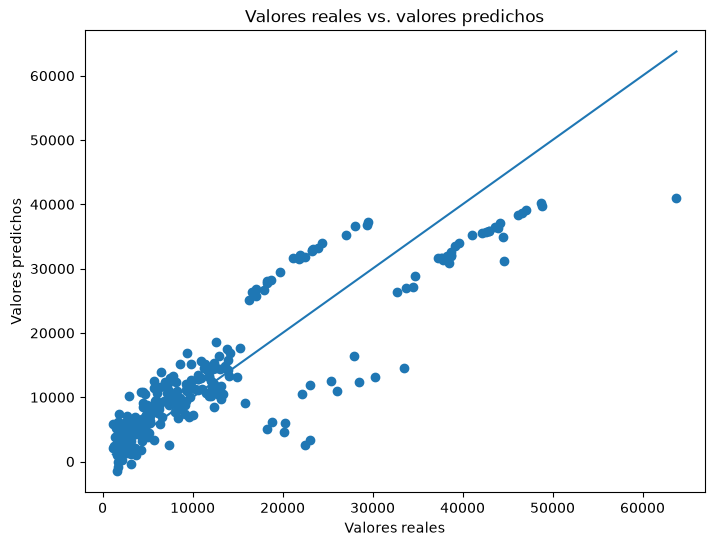

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Valores reales vs. valores predichos")

plt.show()

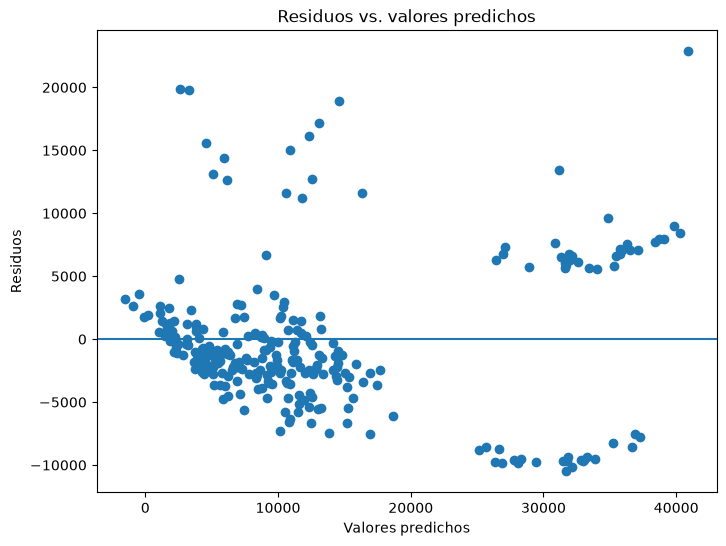

In [17]:
#Analisis de residuos

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, comparacion["Error"])

plt.axhline(y=0)

plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Residuos vs. valores predichos")

plt.show()


### Lectura del gráfico

**1. ¿En qué rango de costos predice mejor el modelo y en cuál peor?**

El modelo predice mejor los costos **bajos y medios**, aproximadamente entre **0 y 20.000 dólares**, donde varios puntos se encuentran relativamente cerca de la diagonal. En cambio, predice peor los costos **altos**, especialmente por encima de **20.000 dólares**, donde los puntos presentan mayor dispersión.

**2. ¿Los puntos alejados están por encima o por debajo de la diagonal y qué significa eso?**

Se observan puntos alejados tanto **por encima como por debajo** de la diagonal.

* **Por encima de la diagonal:** el modelo está **sobreestimando** el costo, es decir, predice un valor mayor que el real.
* **Por debajo de la diagonal:** el modelo está **subestimando** el costo, es decir, predice un valor menor que el real.

Los errores más grandes aparecen principalmente en los costos altos.

**3. ¿Observas grupos de puntos separados?**

Sí, se puede observar cierta separación en los puntos. Una posible razón es que existen diferentes tipos de asegurados, especialmente entre **fumadores y no fumadores**, cuyos costos presentan diferencias importantes.

**4. Hipótesis sobre los asegurados que provocan los mayores errores**

Una posible hipótesis es que los mayores errores corresponden a **asegurados fumadores**, especialmente aquellos que además presentan un **BMI alto o mayor edad**. Estos asegurados pueden tener costos reales muy elevados y la regresión lineal puede tener dificultades para representar completamente ese comportamiento.


In [18]:
#Predecir el costo de nuevos solicitantes
nuevos = pd.DataFrame({
    "age": [45, 45, 25],
    "sex": ["male", "male", "female"],
    "bmi": [33.5, 33.5, 22.0],
    "children": [2, 2, 0],
    "smoker": ["yes", "no", "no"],
    "region": ["southeast", "southeast", "northwest"]
})

nuevos = pd.get_dummies(nuevos, drop_first=True)

nuevos = nuevos.reindex(columns=X.columns, fill_value=0)

predicciones = modelo.predict(nuevos)

for i, costo in enumerate(predicciones, 1):
    print(f"Solicitante {chr(64+i)}: costo estimado = {costo:.2f}")

Solicitante A: costo estimado = 34750.52
Solicitante B: costo estimado = 11099.39
Solicitante C: costo estimado = 1909.21



**1. ¿Por qué es necesario el paso de `reindex`? ¿Qué ocurriría sin él?**

El paso `reindex(columns=X.columns, fill_value=0)` es necesario para que los nuevos solicitantes tengan **exactamente las mismas columnas y en el mismo orden** que los datos utilizados para entrenar el modelo.

Sin este paso, podrían faltar algunas columnas o estar en un orden diferente. Esto podría provocar un error al realizar la predicción o hacer que los datos no sean interpretados correctamente por el modelo.

**2. Los solicitantes A y B solo difieren en una característica: ¿cuánto cambia la predicción entre ellos?**

Los solicitantes A y B tienen las mismas características excepto `smoker`:

* A: `smoker = yes`
* B: `smoker = no`

Sus predicciones son:

* A = **34,750.52 dólares**
* B = **11,099.39 dólares**

Por lo tanto, la diferencia es:

$$
34750.52 - 11099.39 = 23651.13
$$

La predicción cambia en aproximadamente **23,651.13 dólares**.

Esta diferencia coincide con el coeficiente de **`smoker_yes`**, obtenido en el Paso 07, que es aproximadamente **23,651.13 dólares**.

Esto significa que, manteniendo las demás características constantes, ser fumador aumenta el costo estimado del seguro en aproximadamente **23,651.13 dólares** respecto a la categoría de referencia, que es **no fumador**.


### Conclusión

En esta práctica se desarrolló un modelo de **regresión lineal múltiple** para predecir el costo anual de un seguro médico a partir de variables como la edad, BMI, número de hijos, sexo, condición de fumador y región. Los datos categóricos fueron transformados mediante `get_dummies`, permitiendo que el modelo pudiera utilizarlos en sus cálculos.

El modelo obtuvo un **R² de 0.7836**, lo que indica que aproximadamente el **78.36 % de la variación de los costos** puede ser explicada por las variables utilizadas. Además, se obtuvo un **MAE de 4181.19 dólares**, mostrando que las predicciones presentan un error promedio considerable, especialmente en algunos asegurados con costos elevados.

La interpretación de los coeficientes permitió identificar que la variable **`smoker_yes`** tiene el mayor efecto sobre el costo estimado. Ser fumador aumenta la predicción aproximadamente en **23,651.13 dólares** respecto a una persona no fumadora, manteniendo las demás variables constantes. Esto también se comprobó al comparar los solicitantes A y B.

Finalmente, el modelo es **aceptable como una primera aproximación**, ya que logra explicar una parte importante de la variación de los costos. Sin embargo, presenta mayores errores en algunos casos, principalmente en costos altos, por lo que podría mejorarse utilizando otros modelos o incorporando nuevas variables que permitan representar mejor las características de los asegurados.
